In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import joblib
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r"D:\AI Business Recomendation\datasets\coimbatore_business_dataset.csv")
print(df.head())

  Business_ID  Area_Name        Zone   Area_Type   Latitude  Longitude  \
0    CBF00001  Town Hall     Central       Urban  10.994240  76.976104   
1    CBF00002  Kalapatti        East  Semi-Urban  11.086912  77.042126   
2    CBF00003  Ganapathy  North East       Urban  11.035932  77.002969   
3    CBF00004    Podanur       South  Semi-Urban  10.951253  76.981148   
4    CBF00005  Peelamedu        East       Urban  11.023652  77.037977   

     Business_Type    Business_Category  Nearby_Similar_Shops  \
0  Car Wash Center           Automobile                    15   
1     Welding Shop           Automobile                    10   
2    Luggage Store  Fashion & Lifestyle                     7   
3    Cloud Kitchen      Food & Beverage                    18   
4       Juice Shop      Food & Beverage                    16   

  Competition_Level  ...  Public_Service_Nearby  Commercial_Facilities_Nearby  \
0              High  ...                    Yes                        Medium   
1 

In [3]:
print(df.shape)
print(df.info())
print(df['Feasibility_Label'].value_counts())

(5000, 30)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Business_ID                       5000 non-null   str    
 1   Area_Name                         5000 non-null   str    
 2   Zone                              5000 non-null   str    
 3   Area_Type                         5000 non-null   str    
 4   Latitude                          5000 non-null   float64
 5   Longitude                         5000 non-null   float64
 6   Business_Type                     5000 non-null   str    
 7   Business_Category                 5000 non-null   str    
 8   Nearby_Similar_Shops              5000 non-null   int64  
 9   Competition_Level                 5000 non-null   str    
 10  Market_Saturation_Score           5000 non-null   int64  
 11  Nearby_Business_Count             5000 non-null   int64  
 12  Busine

In [4]:
df = df.drop(columns=[
    'Business_ID',
    'Recommended_Alternative_Business',
    'Feasibility_Score',
    'Success_Probability_Percent'
])

In [5]:
encoder = LabelEncoder()
cols = [
    'Area_Name',
    'Zone',
    'Area_Type',
    'Business_Type',
    'Business_Category',
    'Competition_Level',
    'Parking_Availability',
    'Public_Service_Nearby',
    'Commercial_Facilities_Nearby',
    'Feasibility_Label'
]

for col in cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   Area_Name  Zone  Area_Type   Latitude  Longitude  Business_Type  \
0         27     0          2  10.994240  76.976104             34   
1          4     1          1  11.086912  77.042126            242   
2          1     3          2  11.035932  77.002969            131   
3         15     4          1  10.951253  76.981148             46   
4         13     1          2  11.023652  77.037977            121   

   Business_Category  Nearby_Similar_Shops  Competition_Level  \
0                  1                    15                  0   
1                  1                    10                  2   
2                  4                     7                  2   
3                  5                    18                  0   
4                  5                    16                  0   

   Market_Saturation_Score  ...  Distance_to_Main_Road_m  \
0                       71  ...                      268   
1                       43  ...                     1121   
2       

In [7]:
X = df[[
    'Area_Name',
    'Zone',
    'Area_Type',
    'Latitude',
    'Longitude',
    'Business_Type',
    'Business_Category',
    'Nearby_Similar_Shops',
    'Competition_Level',
    'Market_Saturation_Score',
    'Nearby_Business_Count',
    'Business_Diversity_Score',
    'Population_Density_per_sqkm',
    'Customer_Demand_Score',
    'Average_Daily_Footfall',
    'Road_Connectivity_Score',
    'Distance_to_Main_Road_m',
    'Distance_to_Bus_Stop_m',
    'Parking_Availability',
    'Public_Service_Nearby',
    'Commercial_Facilities_Nearby',
    'Average_Rent_per_month_INR',
    'Startup_Cost_Estimate_INR',
    'Urban_Rural_Market_Index',
    'Growth_Opportunity_Score'
]]

y = df['Feasibility_Label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = KNeighborsClassifier(n_neighbors=5, n_jobs=1)
model.fit(X_train, y_train)
print("KNN Model Trained")

KNN Model Trained


In [10]:
y_pred = model.predict(X_test)
print(y_pred[:10])

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[1 1 2 1 1 1 1 1 2 2]
Accuracy: 0.904


In [11]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred, zero_division=0))

[[  0   0   4]
 [  0 787  35]
 [  0  57 117]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.93      0.96      0.94       822
           2       0.75      0.67      0.71       174

    accuracy                           0.90      1000
   macro avg       0.56      0.54      0.55      1000
weighted avg       0.90      0.90      0.90      1000



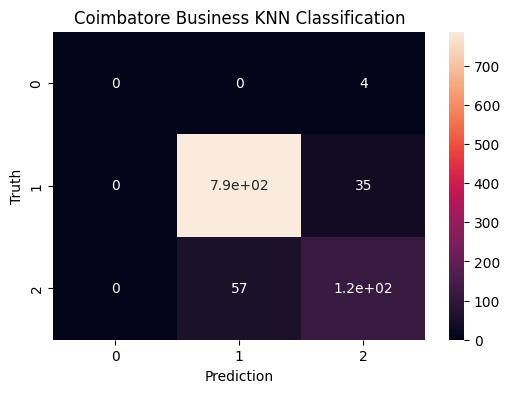

In [12]:
plt.figure(figsize=(6,4))
sn.heatmap(cm, annot=True)
plt.title("Coimbatore Business KNN Classification")
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()

In [13]:
joblib.dump(model, "coimbatore_knn_model.pkl")
joblib.dump(scaler, "coimbatore_knn_scaler.pkl")
print("KNN Model Saved")

KNN Model Saved
